In [1]:
import numpy as np
import os
from pathlib import Path
import pandas as pd

from astropy.io import fits
from astropy.table import Table
from astropy.table import join
from astropy.table import vstack
from astropy.table import Column
import fitsio

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
plt.style.use('dark_background')
cmap = sns.color_palette('mako', as_cmap=True)

### Fisher matrix

$$F_{\alpha\beta} = \frac{\partial \mathbf{O}^{T}}{\partial \theta_{\alpha}} \, \mathbf{C}^{-1} \, \frac{\partial \mathbf{O}}{\partial \theta_{\beta}}$$


$\mathbf{O}$ would be my vector of observables

$\theta$ the cosmological param
$$\theta = \{\omega_b,\omega_{\mathrm{cdm}},n_s,\sigma_8\}$$

$\mathbf{C}$ the cov matrix

--------> I have ASTRA classification/probabilities

1. Use astra probability as a marker:

$$\mathbf{O} = \left[ \frac{P_{\mathrm{void}}(k)}
{P(k)},
\,
\frac{P_{\mathrm{sheet}}(k)}
     {P(k)},
\,
\frac{P_{\mathrm{fil}}(k)}
     {P(k)},
\,
\frac{P_{\mathrm{knot}}(k)}
     {P(k)}
\right]$$

Using ``hod091``

In [2]:
base_path = Path('/pscratch/sd/v/vtorresg/marked_pk')

In [3]:
cosmo_ids = ['100', '101', '102', '103', '104', '105', '112', '113']
c_hod = '091'

In [4]:
cosmo = {cid: pd.read_csv(base_path / f'c{cid}' / f'hod{c_hod}' / f'pk_pypower_HOD_c{cid}_ph000_seed0_hod{c_hod}_N256.csv')
         for cid in cosmo_ids}

In [5]:
cosmo['100'].columns

Index(['k_h_mpc', 'pk_raw', 'pk_used', 'nmodes', 'pk_window', 'pk_over_window',
       'pk_marked_raw_pvoid', 'pk_marked_used_pvoid',
       'pk_marked_over_unmarked_pvoid', 'pk_marked_over_unmarked_masked_pvoid',
       'delta_pk_marked_minus_unmarked_pvoid', 'pk_marked_raw_psheet',
       'pk_marked_used_psheet', 'pk_marked_over_unmarked_psheet',
       'pk_marked_over_unmarked_masked_psheet',
       'delta_pk_marked_minus_unmarked_psheet', 'pk_marked_raw_pfilament',
       'pk_marked_used_pfilament', 'pk_marked_over_unmarked_pfilament',
       'pk_marked_over_unmarked_masked_pfilament',
       'delta_pk_marked_minus_unmarked_pfilament', 'pk_marked_raw_pknot',
       'pk_marked_used_pknot', 'pk_marked_over_unmarked_pknot',
       'pk_marked_over_unmarked_masked_pknot',
       'delta_pk_marked_minus_unmarked_pknot'],
      dtype='object')

In [6]:
classes = ['pvoid', 'psheet', 'pfilament', 'pknot']

obs_cols = [f'pk_marked_over_unmarked_{c}' for c in classes]

get something like ``k0_pvoid, k0_psheet, k0_pfilament, k0_pknot``

In [7]:
O = {cid: cosmo[cid][obs_cols].to_numpy().ravel() for cid in cosmo_ids}

O_mat = np.vstack([O[cid] for cid in cosmo_ids])
O_mat

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(8, 512))

Take out the ones with nan values

and might be better to get something like ``pvoid(k0...kN), psheet(k0...kN), pfilament(k0...kN), pknot(k0...kN)``

In [8]:
mask_k = np.ones(len(cosmo['100']), dtype=bool)

for cid in cosmo_ids:
    mask_k &= np.isfinite(cosmo[cid][obs_cols]).all(axis=1)

In [9]:
O = {cid: cosmo[cid].loc[mask_k, obs_cols].to_numpy().T.ravel()
    for cid in cosmo_ids}

O_mat = np.vstack([O[cid] for cid in cosmo_ids])
O_mat

array([[0.50485938, 0.47918132, 0.51607459, ..., 1.03511171, 1.03381916,
        1.03471708],
       [0.44296684, 0.43036145, 0.45456833, ..., 1.01475243, 1.01420691,
        1.0149883 ],
       [0.50258188, 0.49360543, 0.5164728 , ..., 1.03313643, 1.03188608,
        1.03034387],
       ...,
       [0.40380606, 0.40832036, 0.42202049, ..., 1.00848079, 1.00812077,
        1.00900324],
       [0.50392736, 0.52863982, 0.54319918, ..., 1.08720706, 1.08567859,
        1.08521788],
       [0.42479844, 0.40734016, 0.43873019, ..., 1.00869711, 1.00919317,
        1.00931027]], shape=(8, 504))

In [10]:
O_mat.shape

(8, 504)

| Cosmo |  |
|------------|-------------|
| c000 | fiducial |
| c100 | $+\omega_b$ |
| c101 | $-\omega_b$ |
| c102 | $+\omega_{\mathrm{cdm}}$ |
| c103 | $-\omega_{\mathrm{cdm}}$ |
| c104 | $+n_s$ |
| c105 | $-n_s$ |
| c112 | $+\sigma_8$ |
| c113 | $-\sigma_8$ |

for c100,c101 and c102,c103 the changes are log:  $\pm 2\% \ln{(\omega_b)}$

In [11]:
#fiducial c000
omega_b = 0.02237
omega_cdm = 0.12000
n_s = 0.96490
sigma8_m = 0.807952
sigma8_cb = 0.811355

| param          | cosmo + | cosmo - |  val + |  val - |                   delta    |
| ------------------ | ------------ | ------------ | -------: | -------: | -------------------------------: |
| $\omega_b$         | c100         | c101         |  0.02282 |  0.02193 |    0.00089 |
| $\omega_{\rm cdm}$ | c102         | c103         |  0.12400 |  0.11610 |    0.00790 |
| $n_s$              | c104         | c105         |  0.97490 |  0.95490 |    0.02000 |
| $\sigma_8$         | c112         | c113         | 0.824120 | 0.792107 | 0.032013 |


In [12]:
delta_wb = 0.02282 - 0.02193
delta_ln_wb = 0.04

delta_wcdm = 0.12400 - 0.11610
delta_ln_wcdm = 0.066

delta_ns = 0.97490 - 0.95490
delta_sigma8 = 0.824120 - 0.792107

$2 \Delta \theta = \theta_+ - \theta_-$

$$\frac{\partial \mathcal{O}}{\partial \omega_b}
\approx
\frac{\mathcal{O}_{c100}-\mathcal{O}_{c101}}{0.00089}$$

In [13]:
dO_dwb = (O['100'] - O['101']) / delta_wb
# dO_dlnwb = (O['100'] - O['101']) / delta_ln_wb

$$\frac{\partial \mathcal{O}}{\partial \omega_{\mathrm{cdm}}}
\approx
\frac{\mathcal{O}_{c102}-\mathcal{O}_{c103}}{0.00790}$$

In [14]:
dO_dwcdm = (O['102'] - O['103']) / delta_wcdm
# dO_dlnwcdm = (O['102'] - O['103']) / delta_ln_wcdm

$$\frac{\partial \mathcal{O}}{\partial n_s}
\approx
\frac{\mathcal{O}_{c104}-\mathcal{O}_{c105}}{0.02000}$$

In [15]:
dO_dns = (O['104'] - O['105']) / delta_ns

$$\frac{\partial \mathcal{O}}{\partial \sigma_8}
\approx
\frac{\mathcal{O}_{c112}-\mathcal{O}_{c113}}{0.032013}$$

In [16]:
dO_dsigma8 = (O['112'] - O['113']) / delta_sigma8

In [17]:
D = np.vstack([dO_dwb, dO_dwcdm, dO_dns, dO_dsigma8,])
D.shape

(4, 504)

In [18]:
param_names = [r'$\omega_b$',
               r'$\omega_{\rm cdm}$',
               r'$n_s$',
               r'$\sigma_8$']

#### Check

In [19]:
Nk = mask_k.sum()
k = cosmo['100'].loc[mask_k, 'k_h_mpc'].to_numpy()

In [20]:
derivatives = {param_names[0]: dO_dwb,
               param_names[1]: dO_dwcdm,
               param_names[2]: dO_dns,
               param_names[3]: dO_dsigma8}

In [21]:
# for j, (par, dO) in enumerate(derivatives.items()):
#     plt.figure(figsize=(7, 5))

#     for i, c in enumerate(classes):
#         y = dO[i*Nk:(i+1)*Nk]
#         plt.plot(k, y, label=c)

#     plt.axhline(0, ls='--', color='white', alpha=0.5)
#     plt.grid(lw=0.3, alpha=0.25)
    
#     plt.xscale('log')
#     plt.xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
#     plt.ylabel(rf'$\partial O / \partial ${par}')
#     plt.title(f'HOD{c_hod}')
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(f'./plots/deriv/deriv_hod{c_hod}_param_{j}.png', dpi=360)
#     plt.show()

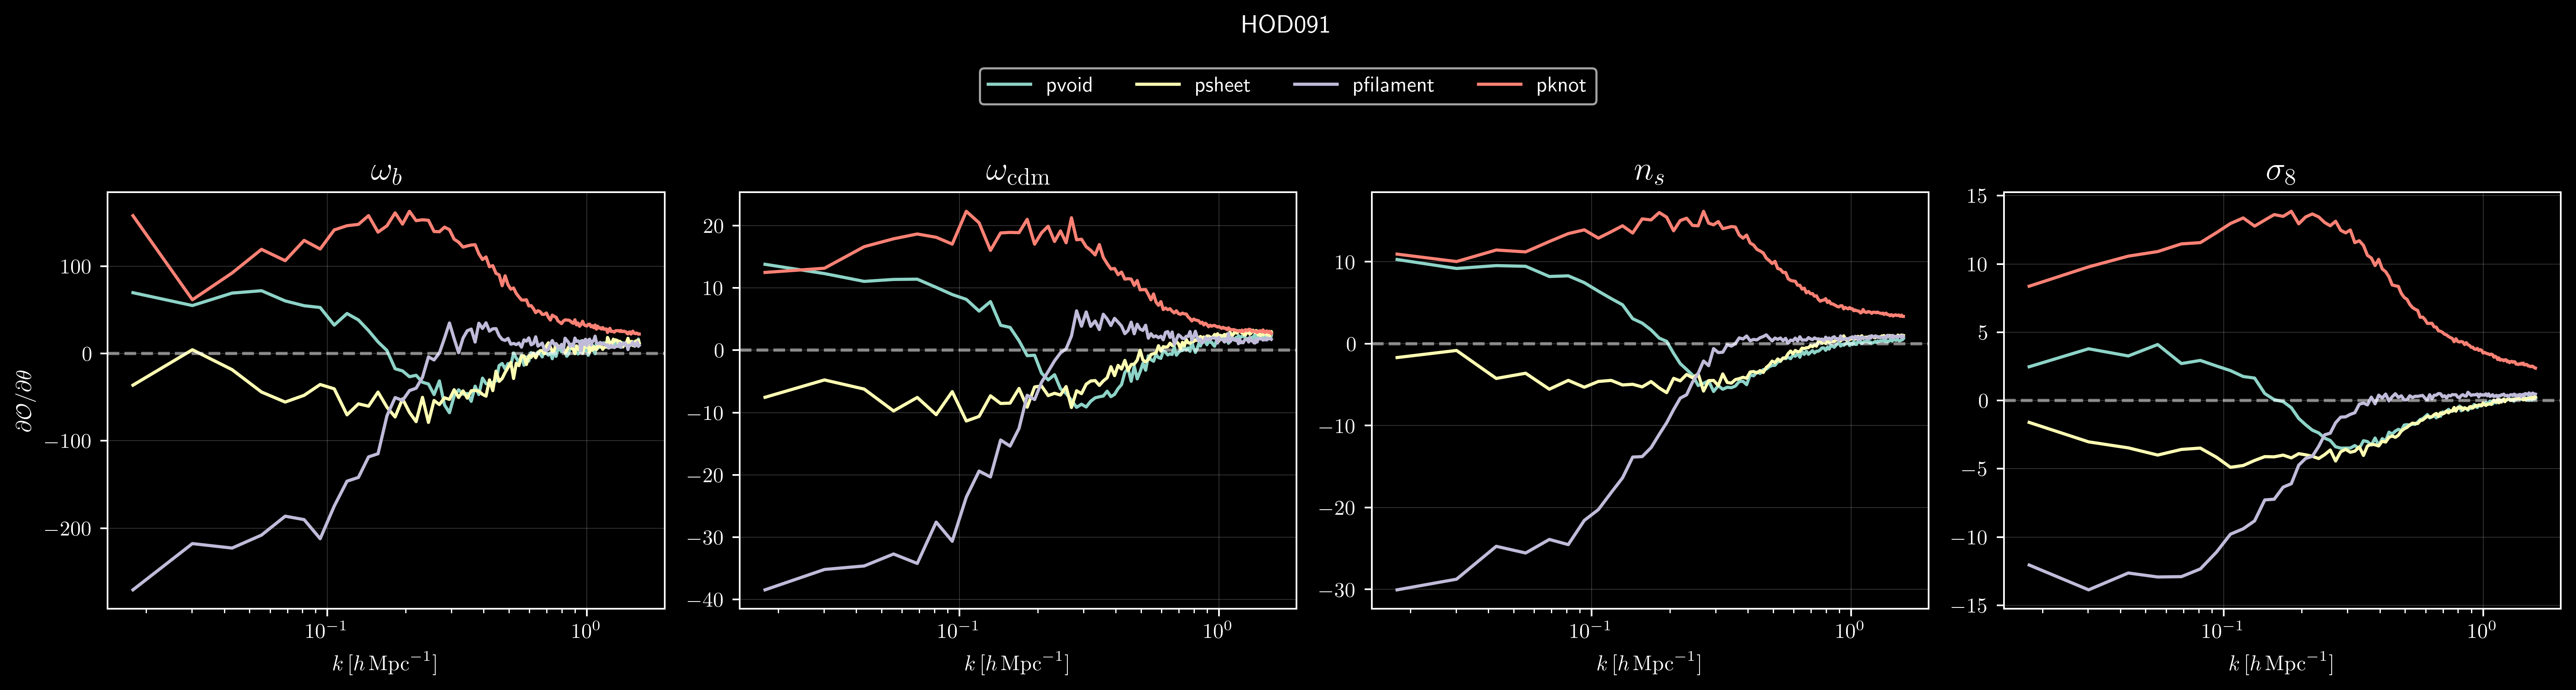

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharex=True)

for j, ((par, dO), ax) in enumerate(zip(derivatives.items(), axes)):

    for i, c in enumerate(classes):
        y = dO[i*Nk:(i+1)*Nk]
        ax.plot(k, y, label=c)

    ax.axhline(0, ls='--', color='white', alpha=0.5)
    ax.grid(lw=0.3, alpha=0.25)
    ax.set_xscale('log')

    ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
    ax.set_title(param_names[j], fontsize=16)

axes[0].set_ylabel(r'$\partial \mathcal{O} / \partial \theta$')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(classes), bbox_to_anchor=(0.5, 1.05))

fig.suptitle(f'HOD{c_hod}', y=1.12)

plt.tight_layout()
plt.savefig(f'./plots/deriv/deriv_hod{c_hod}_all_params.png',dpi=360,
           bbox_inches='tight')
plt.show()

#### Very noisy -> better to use the mean of dif hod?

$$\left.\frac{\partial \mathcal{O}}{\partial \omega_b}\right|_{\mathrm{hod000}}= \frac{\mathcal{O}_{c100,\mathrm{h000}}-\mathcal{O}_{c101,\mathrm{h000}}}
{\omega_{b,c100}-\omega_{b,c101}}$$

$$\left.\frac{\partial \mathcal{O}}{\partial \omega_b}\right|_{\mathrm{hod001}}=\frac{\mathcal{O}_{c100,\mathrm{h001}}-\mathcal{O}_{c101,\mathrm{h001}}} {\omega_{b,c100}-\omega_{b,c101}}$$

$$\frac{\partial \mathcal{O}}{\partial \omega_b} = \left\langle \left.
 \frac{\partial \mathcal{O}}{\partial \omega_b}
\right|_{\mathrm{hod}}
\right\rangle_{\mathrm{HOD}}$$

all pairs (c100-c101, c102-c103, c104-c105, c112-c113) have dif common hods

In [23]:
base_path = Path('/pscratch/sd/v/vtorresg/marked_pk')

In [24]:
def get_available_hods(cid):
    cosmo_dir = base_path / f'c{cid}'
    hods = []
    for p in cosmo_dir.glob('hod*'):
        if p.is_dir():
            hod_id = p.name.replace('hod', '')
            hods.append(hod_id)
            
    return sorted(hods)


def get_common_hods(cid_plus, cid_minus):
    hods_plus = set(get_available_hods(cid_plus))
    hods_minus = set(get_available_hods(cid_minus))
    common = sorted(hods_plus & hods_minus)
    return common

In [25]:
hods_wb = get_common_hods('100', '101')
hods_wcdm = get_common_hods('102', '103')
hods_ns = get_common_hods('104', '105')
hods_s8 = get_common_hods('112', '113')

In [26]:
pair_hods = {('100', '101'): hods_wb,
             ('102', '103'): hods_wcdm,
             ('104', '105'): hods_ns,
             ('112', '113'): hods_s8}

In [27]:
for pair, hods in pair_hods.items():
    print(pair, len(hods))

('100', '101') 290
('102', '103') 275
('104', '105') 274
('112', '113') 305


In [28]:
def load_pk_dataframe(cid, hod):
    filename = (base_path / f'c{cid}' / f'hod{hod}' /
                f'pk_pypower_HOD_c{cid}_ph000_seed0_hod{hod}_N256.csv')
    return pd.read_csv(filename)

In [29]:
def build_common_mask_for_pair(cid_plus, cid_minus, hod):
    df_plus = load_pk_dataframe(cid_plus, hod)
    df_minus = load_pk_dataframe(cid_minus, hod)
    
    mask = np.isfinite(df_plus[obs_cols]).all(axis=1)
    mask &= np.isfinite(df_minus[obs_cols]).all(axis=1)
    
    return mask

In [30]:
def build_observable_from_df(df, mask):
    return df.loc[mask, obs_cols].to_numpy().T.ravel()

a fixed range in $k$

In [31]:
kmin = 0.02
kmax = 0.20

In [32]:
def compute_pair_derivatives(cid_plus, cid_minus, hods, delta_theta,
                                  kmin=kmin, kmax=kmax):
    dO_all = []
    k_ref = None
    
    for hod in hods:
        df_plus = load_pk_dataframe(cid_plus, hod)
        df_minus = load_pk_dataframe(cid_minus, hod)
        
        mask = np.isfinite(df_plus[obs_cols]).all(axis=1)
        mask &= np.isfinite(df_minus[obs_cols]).all(axis=1)
        mask &= df_plus['k_h_mpc'].between(kmin, kmax)
        
        O_plus = build_observable_from_df(df_plus, mask)
        O_minus = build_observable_from_df(df_minus, mask)
        
        dO = (O_plus - O_minus) / delta_theta
        dO_all.append(dO)
        
        if k_ref is None:
            k_ref = df_plus.loc[mask, 'k_h_mpc'].to_numpy()
    
    dO_all = np.array(dO_all)
    dO_mean = np.mean(dO_all, axis=0)
    dO_err = np.std(dO_all, axis=0) / np.sqrt(len(dO_all))
    
    return dO_mean, dO_err, dO_all, k_ref

In [78]:
def compute_derivative_from_mean_observable(cid_plus, cid_minus, hods, delta_theta,
                                            kmin=kmin, kmax=kmax):
    O_plus_all = []
    O_minus_all = []
    k_ref = None

    for hod in hods:
        df_plus = load_pk_dataframe(cid_plus, hod)
        df_minus = load_pk_dataframe(cid_minus, hod)

        mask = np.isfinite(df_plus[obs_cols]).all(axis=1)
        mask &= np.isfinite(df_minus[obs_cols]).all(axis=1)
        mask &= df_plus['k_h_mpc'].between(kmin, kmax)

        k_this = df_plus.loc[mask, 'k_h_mpc'].to_numpy()

        if k_ref is None:
            k_ref = k_this
        else:
            if len(k_this) != len(k_ref) or not np.allclose(k_this, k_ref):
                raise ValueError(f'k grid mismatch for hod{hod}')

        O_plus = build_observable_from_df(df_plus, mask)
        O_minus = build_observable_from_df(df_minus, mask)

        O_plus_all.append(O_plus)
        O_minus_all.append(O_minus)

    O_plus_all = np.array(O_plus_all)
    O_minus_all = np.array(O_minus_all)

    O_plus_mean = np.mean(O_plus_all, axis=0)
    O_minus_mean = np.mean(O_minus_all, axis=0)

    dO = (O_plus_mean - O_minus_mean) / delta_theta

    return dO, O_plus_mean, O_minus_mean, O_plus_all, O_minus_all, k_ref

In [34]:
steps = {'omega_b': delta_wb,
         'omega_cdm': delta_wcdm,
         'n_s': delta_ns,
         'sigma8': delta_sigma8}

In [36]:
dO_dwb, O_100_mean, O_101_mean, O_100_all, O_101_all, k = compute_derivative_from_mean_observable('100', '101', hods_wb, steps['omega_b'])
dO_dwb.shape

(56,)

In [37]:
dO_dwcdm, O_102_mean, O_103_mean, O_102_all, O_103_all, _ = compute_derivative_from_mean_observable('102', '103', hods_wcdm, steps['omega_cdm'])
dO_dwcdm.shape

(56,)

In [38]:
dO_dns, O_104_mean, O_105_mean, O_104_all, O_105_all, _ = compute_derivative_from_mean_observable('104', '105', hods_ns, steps['n_s'])
dO_dns.shape

(56,)

In [39]:
dO_dsigma8, O_112_mean, O_113_mean, O_112_all, O_113_all, _ = compute_derivative_from_mean_observable('112', '113', hods_s8, steps['sigma8'])
dO_dsigma8.shape

(56,)

In [40]:
D = np.vstack([dO_dwb, dO_dwcdm, dO_dns, dO_dsigma8])
D.shape

(4, 56)

In [41]:
derivative_means = {'omega_b': dO_dwb,
                    'omega_cdm': dO_dwcdm,
                    'n_s': dO_dns,
                    'sigma8': dO_dsigma8}

In [42]:
def derivative_error_from_observable_scatter(O_plus_all, O_minus_all, delta_theta):
    N_plus = O_plus_all.shape[0]
    N_minus = O_minus_all.shape[0]

    var_plus_mean = np.var(O_plus_all, axis=0, ddof=1) / N_plus
    var_minus_mean = np.var(O_minus_all, axis=0, ddof=1) / N_minus

    dO_err = np.sqrt(var_plus_mean + var_minus_mean) / np.abs(delta_theta)

    return dO_err

In [43]:
dO_dwb_err = derivative_error_from_observable_scatter(O_100_all, O_101_all, delta_wb)
dO_dwcdm_err = derivative_error_from_observable_scatter(O_102_all, O_103_all, delta_wcdm)
dO_dns_err = derivative_error_from_observable_scatter(O_104_all, O_105_all, delta_ns)
dO_dsigma8_err = derivative_error_from_observable_scatter(O_112_all, O_113_all, delta_sigma8)

In [44]:
derivative_errs = {'omega_b': dO_dwb_err,
                   'omega_cdm': dO_dwcdm_err,
                   'n_s': dO_dns_err,
                   'sigma8': dO_dsigma8_err}

In [45]:
Nk = len(k)

In [46]:
# for j, par in enumerate(derivative_means):
#     dO = derivative_means[par]
#     err = derivative_errs[par]
    
#     plt.figure(figsize=(7, 5))
    
#     for i, c in enumerate(classes):
#         y = dO[i*Nk:(i+1)*Nk]
#         yerr = err[i*Nk:(i+1)*Nk]
        
#         plt.plot(k, y, label=c)
#         plt.fill_between(k, y - yerr, y + yerr, alpha=0.2)
    
#     plt.axhline(0, ls='--', color='white', alpha=0.5)
#     plt.grid(lw=0.3, alpha=0.25)
#     plt.xscale('log')
    
#     plt.xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
#     plt.ylabel(rf'$\partial O / \partial ${param_names[j]}')
    
#     plt.title(f'Mean derivative over HODs')
    
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(f'./plots/deriv/deriv_mean_hod_{j}.png', dpi=360)
#     plt.show()

In [47]:
# fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharex=True)

# for j, (par, ax) in enumerate(zip(derivative_means.keys(), axes)):
#     dO = derivative_means[par]
#     err = derivative_errs[par]

#     for i, c in enumerate(classes):
#         y = dO[i*Nk:(i+1)*Nk]
#         yerr = err[i*Nk:(i+1)*Nk]

#         ax.plot(k, y, label=c)
#         ax.fill_between(k, y - yerr, y + yerr, alpha=0.2)

#     ax.axhline(0, ls='--', color='white', alpha=0.5)
#     ax.grid(lw=0.3, alpha=0.25)
#     ax.set_xscale('log')

#     ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
#     ax.set_title(param_names[j], fontsize=16)

# axes[0].set_ylabel(r'$\partial \mathcal{O} / \partial \theta$')

# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=len(classes),
#            bbox_to_anchor=(0.5, 1.05))

# fig.suptitle('Mean derivative over HODs', y=1.12)

# plt.tight_layout()
# plt.savefig('./plots/deriv/deriv_mean_hod_all_params.png', dpi=360, bbox_inches='tight')
# plt.show()

In [48]:
plot_params = ['omega_b', 'omega_cdm', 'n_s', 'sigma8']

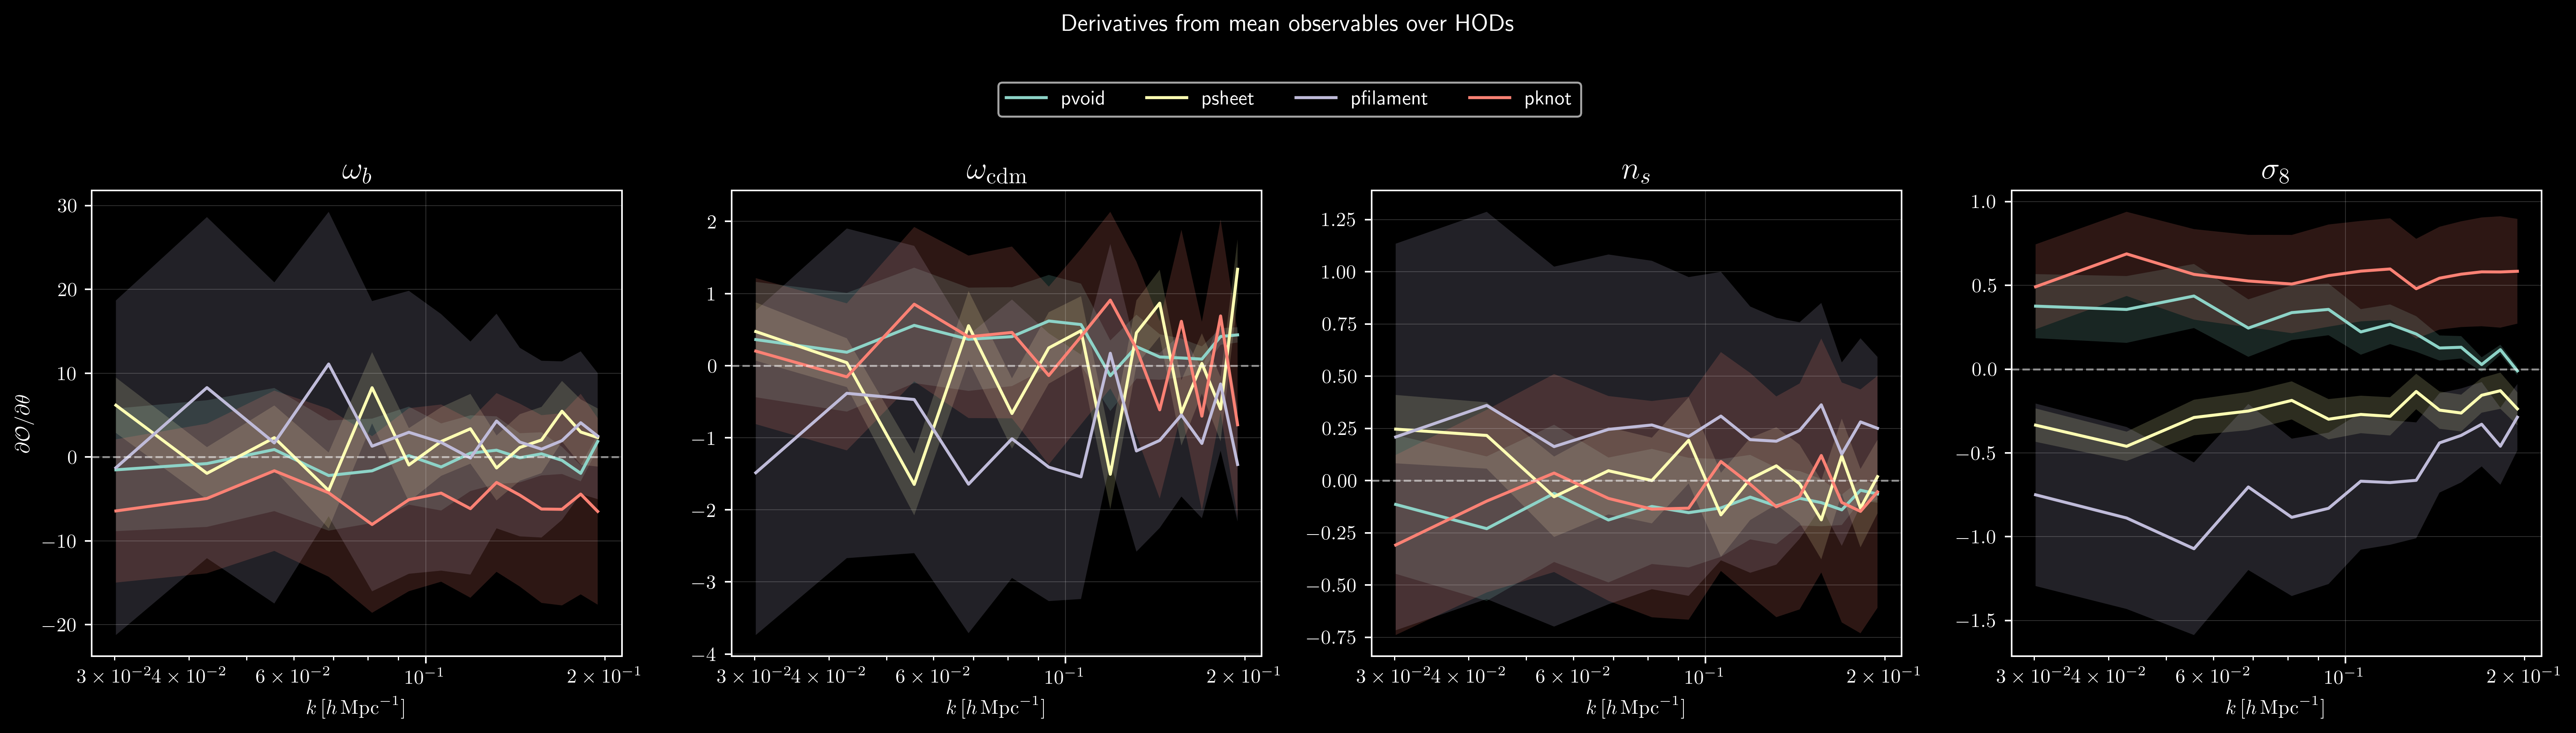

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharex=True)

for j, par in enumerate(plot_params):
    ax = axes[j]

    dO = derivative_means[par]
    err = derivative_errs[par]

    for i, c in enumerate(classes):
        sl = slice(i * Nk, (i + 1) * Nk)

        y = dO[sl]
        yerr = err[sl]

        ax.plot(k, y, lw=1.5, label=c)
        ax.fill_between(k, y - yerr, y + yerr, alpha=0.18)

    ax.axhline(0, ls='--', color='white', alpha=0.5, lw=1.0)
    ax.grid(lw=0.3, alpha=0.25)
    ax.set_xscale('log')

    ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
    ax.set_title(param_names[j], fontsize=16)

axes[0].set_ylabel(r'$\partial \mathcal{O} / \partial \theta$')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(classes), bbox_to_anchor=(0.5, 1.03))

fig.suptitle(r'Derivatives from mean observables over HODs', y=1.12)

fig.tight_layout()
fig.savefig('./plots/deriv/deriv_of_mean_hod_all_params.png', dpi=360, bbox_inches='tight')
plt.show()

In [79]:
len(hods_wb), len(hods_wcdm), len(hods_ns), len(hods_s8)

(290, 275, 274, 305)

#### Covariance

In [50]:
def get_available_hods(cid):
    cosmo_dir = base_path / f'c{cid}'
    
    hods = []
    for p in cosmo_dir.glob('hod*'):
        if p.is_dir():
            hods.append(p.name.replace('hod', ''))
            
    return sorted(hods)

In [51]:
hods_fid = get_available_hods('000')
len(hods_fid)

500

In [52]:
obs_cols = ['pk_marked_over_unmarked_pvoid',
            'pk_marked_over_unmarked_psheet',
            'pk_marked_over_unmarked_pfilament',
            'pk_marked_over_unmarked_pknot']

In [69]:
def build_fiducial_observable_matrix(hods_fid, kmin=kmin, kmax=kmax):
    O_fid_all = []
    k_ref = None
    
    for hod in hods_fid:
        df = load_pk_dataframe('000', hod)
        
        mask = np.isfinite(df[obs_cols]).all(axis=1)
        mask &= df['k_h_mpc'].between(kmin, kmax)
        
        k_this = df.loc[mask, 'k_h_mpc'].to_numpy()
        
        k_ref = k_this
        O = df.loc[mask, obs_cols].to_numpy().T.ravel()
        O_fid_all.append(O)
    
    O_fid_all = np.array(O_fid_all)
    
    return O_fid_all, k_ref

In [71]:
O_fid_all, k_cov = build_fiducial_observable_matrix(hods_fid, kmin=kmin, kmax=kmax)
O_fid_all.shape

(500, 56)

In [72]:
C = np.cov(O_fid_all, rowvar=False)
C.shape

(56, 56)

In [ ]:
std = np.sqrt(np.diag(C))
Corr = C / np.outer(std, std)

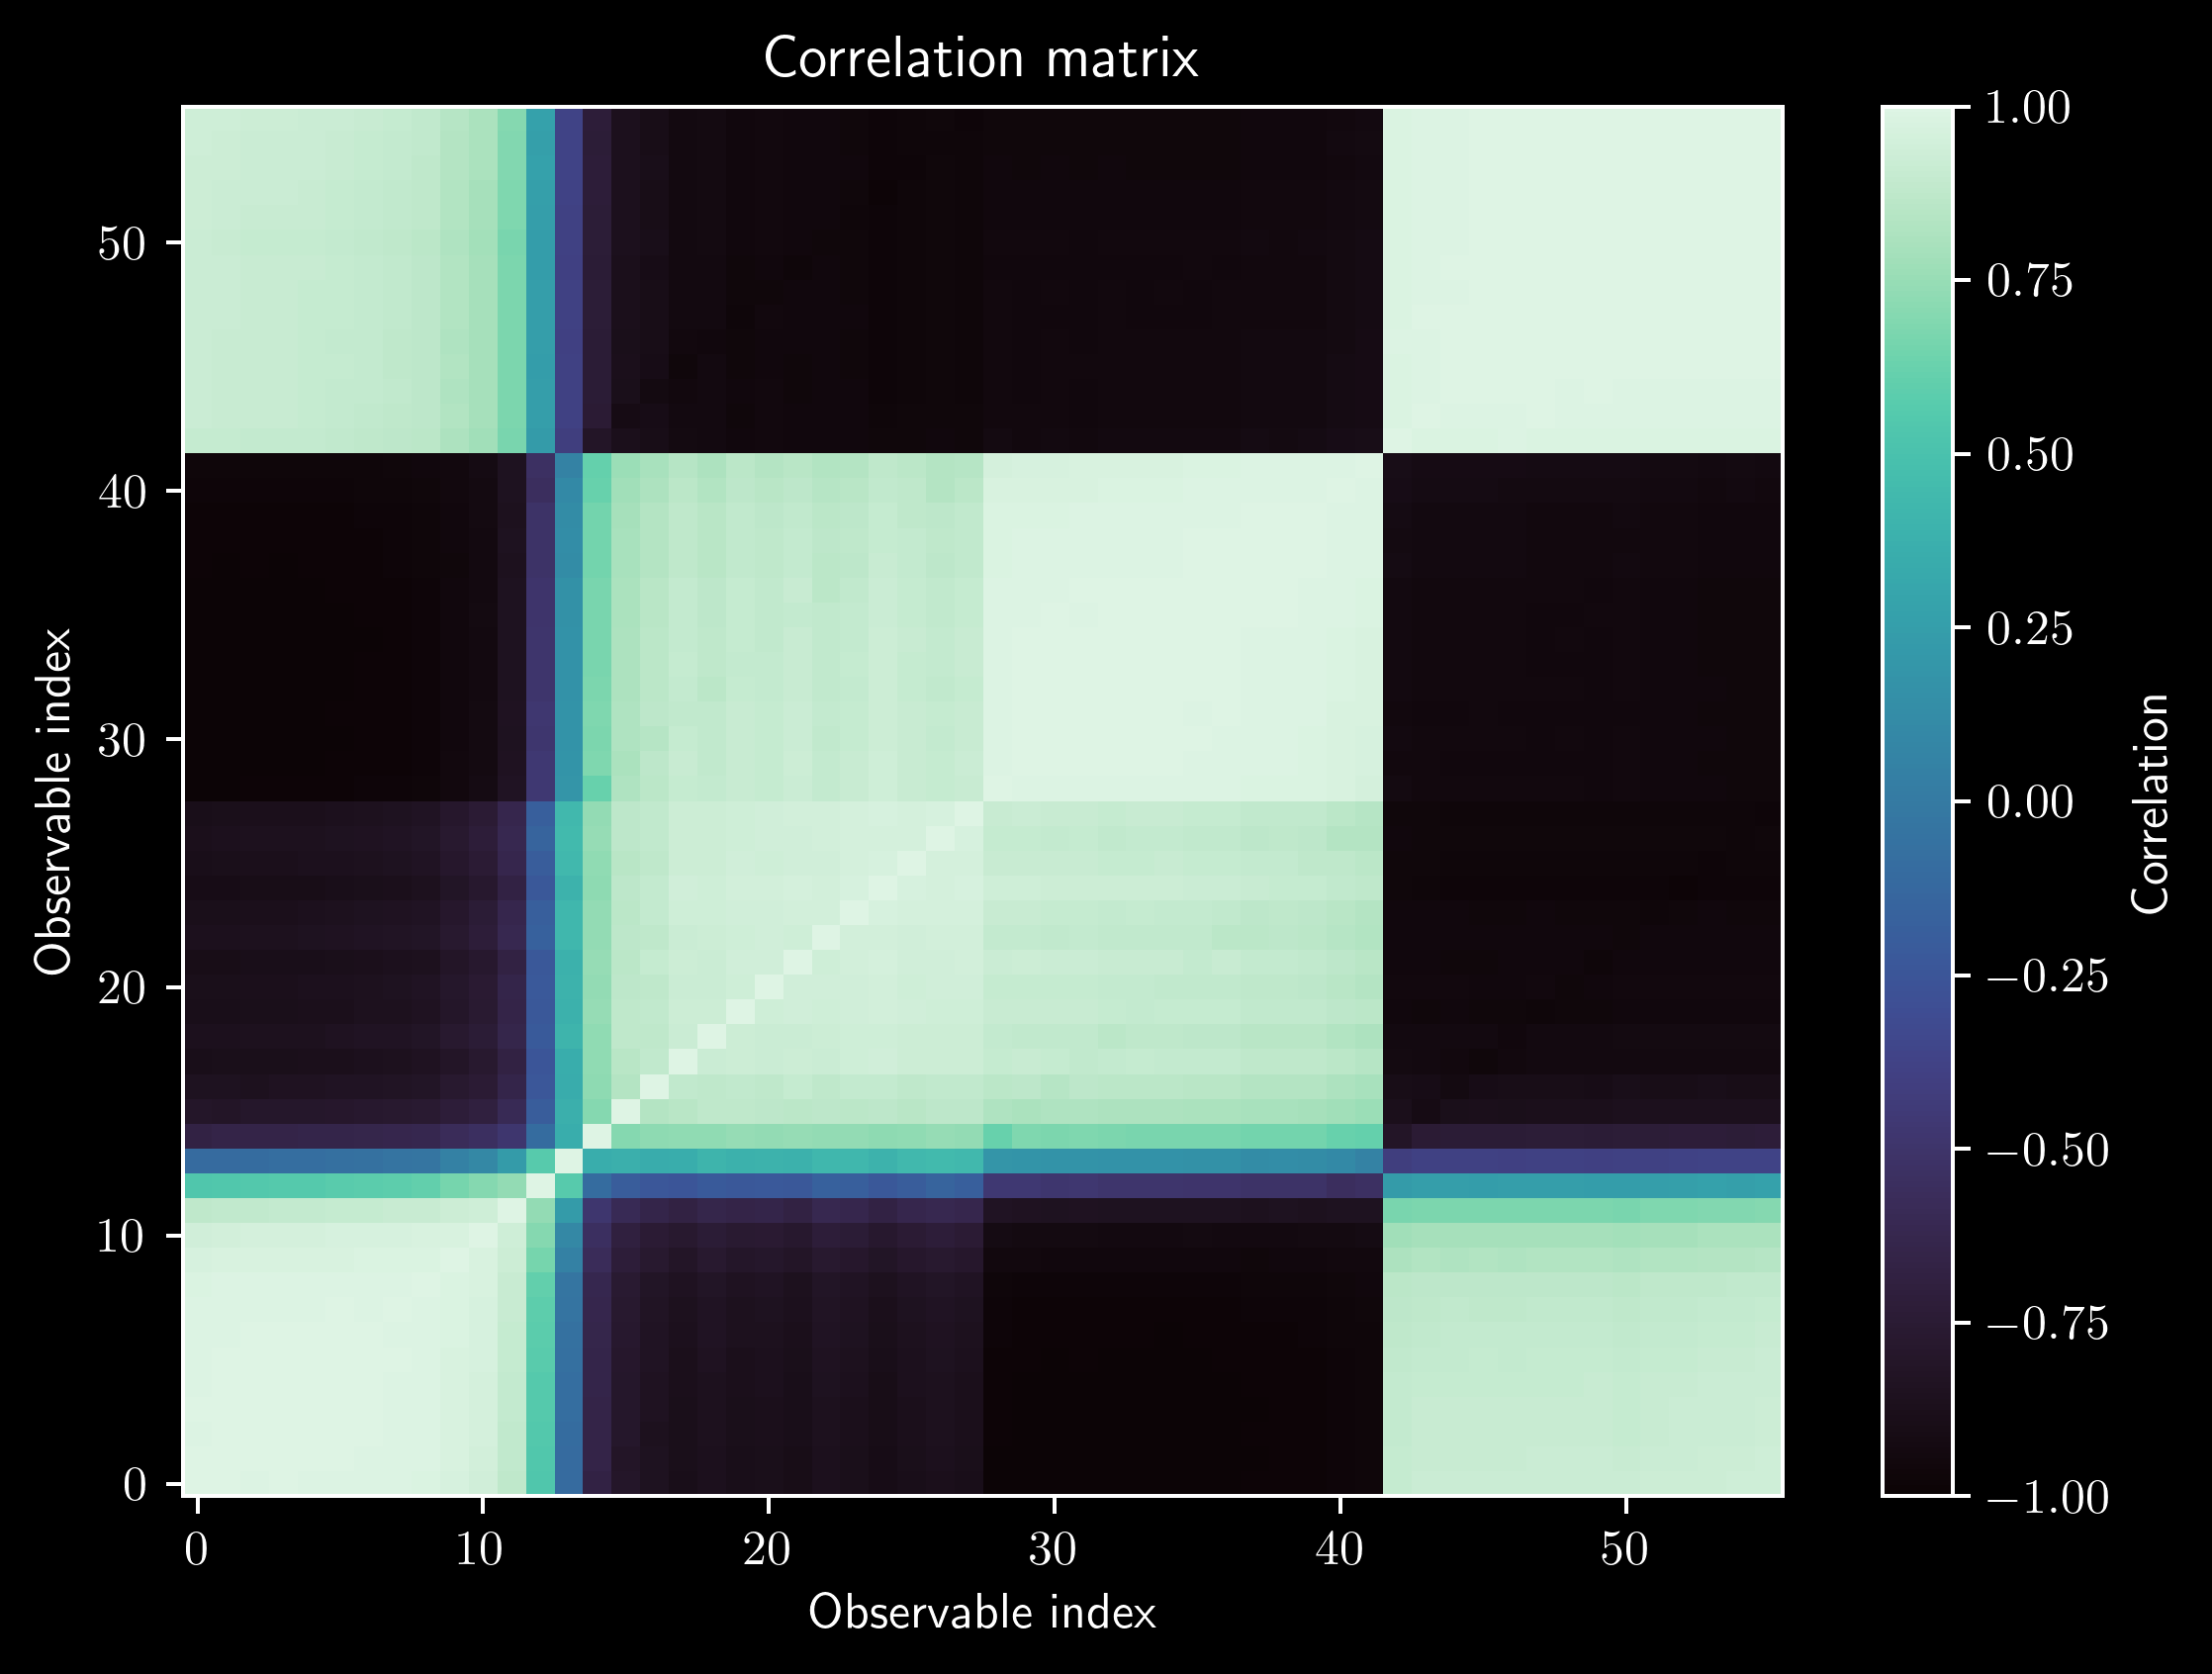

In [74]:
plt.imshow(Corr, vmin=-1, vmax=1, origin='lower', cmap=cmap, aspect='auto')
plt.colorbar(label='Correlation')
plt.xlabel('Observable index')
plt.ylabel('Observable index')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

In [81]:
F = D @ Cinv @ D.T
F

array([[ 3.59384622e+06, -8.10816620e+04, -6.03415227e+03,
         8.79634900e+03],
       [-8.10816620e+04,  3.17159107e+05,  6.03251563e+03,
        -1.67370458e+03],
       [-6.03415227e+03,  6.03251563e+03,  6.15555695e+03,
        -7.33149343e+01],
       [ 8.79634900e+03, -1.67370458e+03, -7.33149343e+01,
         3.41608359e+03]])

In [82]:
param_names = ['omega_b', 'omega_cdm', 'n_s', 'sigma8']
F_df = pd.DataFrame(F, index=param_names, columns=param_names)
F_df

,omega_b,omega_cdm,n_s,sigma8
omega_b,3.593846e+06,-81081.662016,-6034.152268,8796.348999
omega_cdm,-8.108166e+04,317159.106858,6032.515626,-1673.704584
n_s,-6.034152e+03,6032.515626,6155.556953,-73.314934
sigma8,8.796349e+03,-1673.704584,-73.314934,3416.083591


In [83]:
param_cov = np.linalg.inv(F)
sigma_params = np.sqrt(np.diag(param_cov))

for name, sig in zip(param_names, sigma_params):
    print(f'{name}: sigma = {sig:.5e}')

omega_b: sigma = 5.30792e-04
omega_cdm: sigma = 1.79873e-03
n_s: sigma = 1.28726e-02
sigma8: sigma = 1.71815e-02


In [84]:
evals = np.linalg.eigvalsh(F)
evals

array([3.38720322e+03, 6.03335783e+03, 3.15272673e+05, 3.59588373e+06])